# Import Libraries

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load Dataset

In [19]:
df = pd.read_csv(r"C:\Users\divya\OneDrive\DS\EDA\digit-recognizer\train.csv")

# Check Dataset

In [20]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Visualize One Image

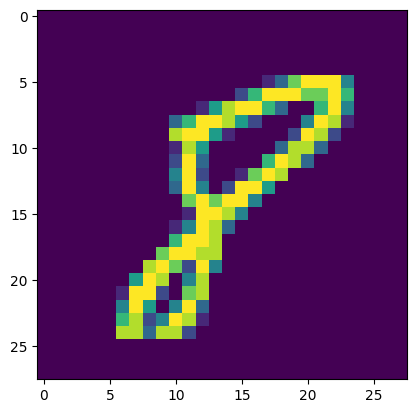

In [21]:
plt.imshow(
    df.iloc[18306,1:].values.reshape(28,28)
)

# Features and Target

In [22]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

# Train Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Check Shape

In [24]:
X_train.shape

(33600, 784)

# KNN Without PCA

In [25]:
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


# Prediction Time

In [26]:
import time

start = time.time()

y_pred = knn.predict(X_test)

print(time.time() - start)

16.629475116729736


# Accuracy Without PCA

In [27]:
accuracy_score(y_test, y_pred)

0.9648809523809524

# Standardization

In [28]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# PCA

In [31]:
pca = PCA(n_components=100)

X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

# Shape After PCA

In [32]:
X_train_trf.shape

(33600, 100)

# KNN With PCA

In [33]:
knn = KNeighborsClassifier()

knn.fit(X_train_trf, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


# Prediction

In [34]:
y_pred = knn.predict(X_test_trf)

# Accuracy With PCA

In [35]:
accuracy_score(y_test, y_pred)

0.9544047619047619

# Accuracy for Different PCA Components

In [36]:
for i in range(1,785):

    pca = PCA(n_components=i)

    X_train_trf = pca.fit_transform(X_train)
    X_test_trf = pca.transform(X_test)

    knn = KNeighborsClassifier()

    knn.fit(X_train_trf, y_train)

    y_pred = knn.predict(X_test_trf)

    print(i, accuracy_score(y_test, y_pred))

1 0.2580952380952381
2 0.3236904761904762
3 0.5104761904761905
4 0.6663095238095238
5 0.7378571428571429


KeyboardInterrupt: 

# Transforming into 2D

In [37]:
pca = PCA(n_components=2)

X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

# Check Transformed Data

In [38]:
X_train_trf

array([[-2.71863253, -0.48982409],
       [-0.67698015, -6.75362491],
       [-3.03323281,  6.50981624],
       ...,
       [ 2.14883643,  0.78079444],
       [ 1.05957006,  0.94767312],
       [17.70258446,  1.96188185]], shape=(33600, 2))

# 2D Visualization

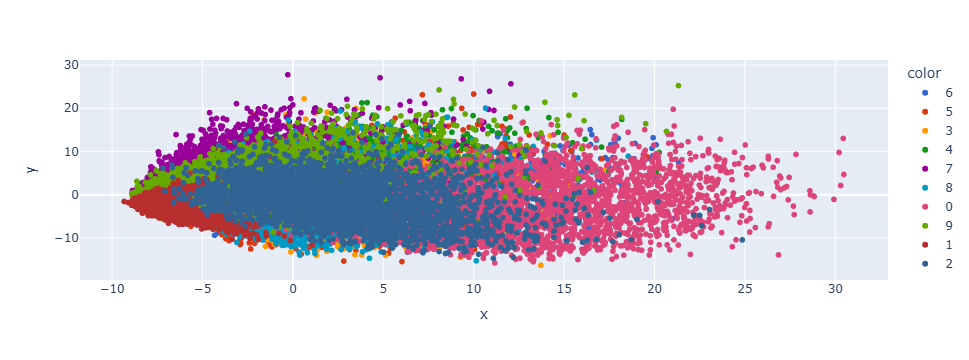

In [39]:
y_train_trf = y_train.astype(str)

fig = px.scatter(
    x=X_train_trf[:,0],
    y=X_train_trf[:,1],
    color=y_train_trf,
    color_discrete_sequence=px.colors.qualitative.G10
)

fig.show()

# Transforming into 3D

In [49]:
pca = PCA(n_components=3)

X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

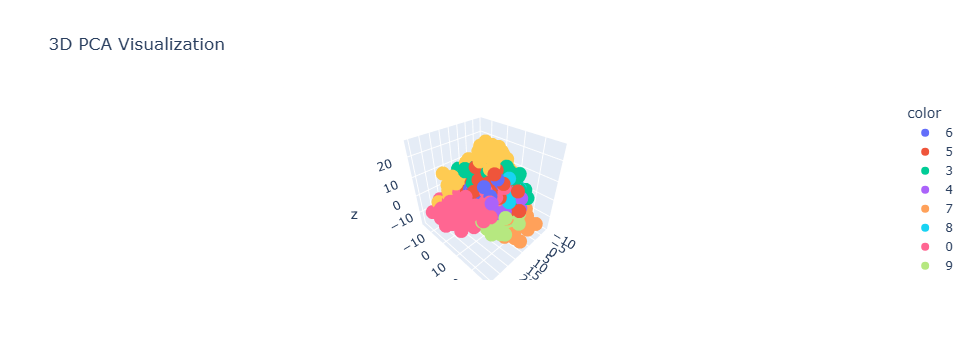

In [40]:
#3d visualization
# Import Library
import plotly.express as px

# PCA in 3D
pca = PCA(n_components=3)

X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

# Convert labels into string
y_train_trf = y_train.astype(str)

# 3D Scatter Plot
fig = px.scatter_3d(
    x=X_train_trf[:,0],
    y=X_train_trf[:,1],
    z=X_train_trf[:,2],
    color=y_train_trf,
    title="3D PCA Visualization"
)

fig.show()

# Check 3D Data

In [42]:
X_train_trf

array([[-2.71863253, -0.48982409,  1.1354966 ],
       [-0.67698015, -6.75362491, -2.33590139],
       [-3.03323281,  6.50981624,  7.49182983],
       ...,
       [ 2.14883643,  0.78079444, -0.74738774],
       [ 1.05957006,  0.94767312,  3.94973114],
       [17.70258446,  1.96188185, -4.94352837]], shape=(33600, 3))

# Eigen Values

In [43]:
pca.explained_variance_  

array([40.67111198, 29.17023401, 26.74459621])

# PCA Components(eigen vectors) Shape

In [54]:
pca.components_.shape 

(2, 4)

# Explained Variance Shape

In [45]:
pca.explained_variance_.shape

(3,)

# Explained Variance Ratio

In [46]:
pca.explained_variance_ratio_  # which pc is explaining how much variance in data

array([0.05785192, 0.0414927 , 0.03804239])

# Cumulative Sum

In [47]:
np.cumsum(
    pca.explained_variance_ratio_
)

array([0.05785192, 0.09934462, 0.13738701])

# Plot Cumulative Variance

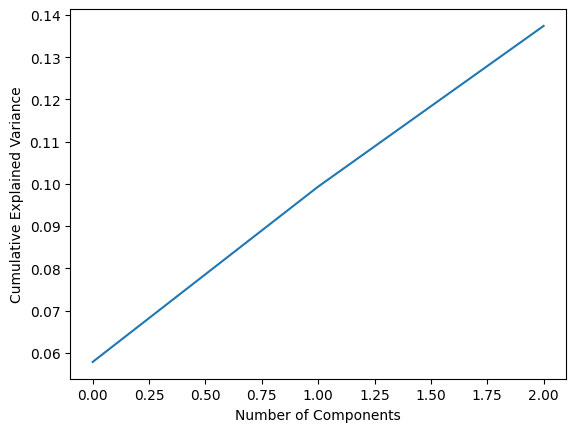

In [48]:
plt.plot(
    np.cumsum(
        pca.explained_variance_ratio_
    )
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.show()

# COMPLETE WORKFLOW

Original Shape : (150, 4)
PCA Shape : (150, 2)

Explained Variance Ratio:
[0.72962445 0.22850762]


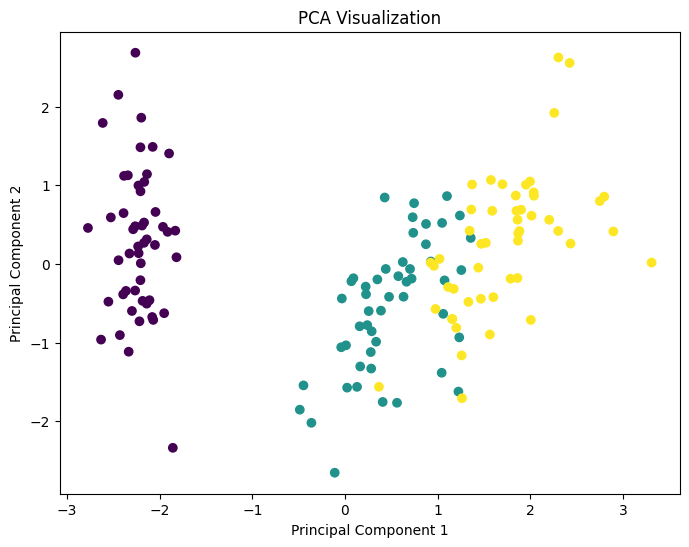

In [49]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load Dataset
iris = load_iris()

X = iris.data
y = iris.target

# Standardization
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# Shape
print("Original Shape :", X.shape)
print("PCA Shape :", X_pca.shape)

# Explained Variance
print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

# Visualization
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA Visualization")

plt.show()